<a href="https://colab.research.google.com/github/smiritisi-msc26-lgtm/BPTA/blob/main/ApproxVertex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

m(Edges)  | Matching Size   | Vertex Cover Size   | Optimal VC Size   | Approx. Factor  | Running Time (seconds)   
-------------------------------------------------------------------------------------------------------------------
10        | 4               | 8                   | 5                 | 1.60            | 0.00002058               
Matching = [(6, 8), (0, 2), (1, 7), (4, 9)]
Vertex Cover = (0, 1, 2, 4, 6, 7, 8, 9)



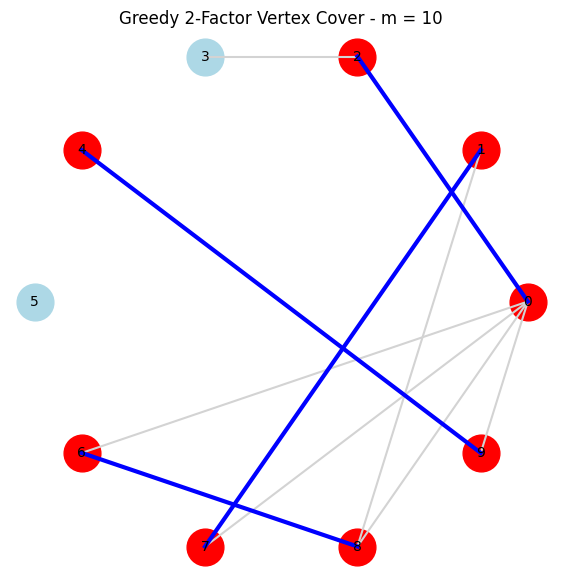

15        | 4               | 8                   | 5                 | 1.60            | 0.00002839               
Matching = [(5, 8), (3, 7), (0, 2), (1, 6)]
Vertex Cover = (0, 1, 2, 3, 5, 6, 7, 8)



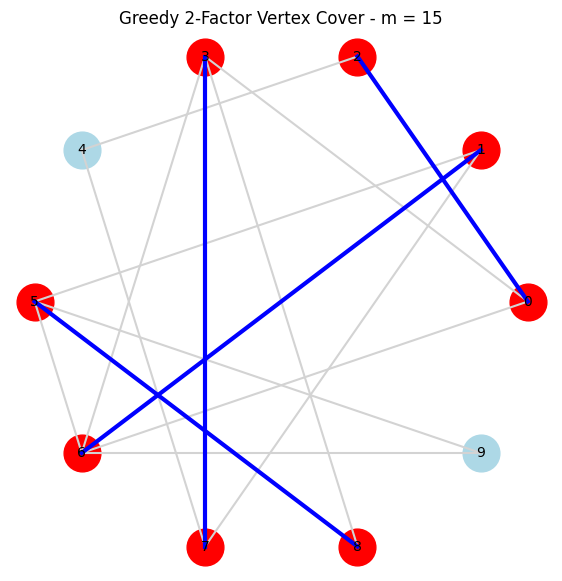

20        | 4               | 8                   | 6                 | 1.33            | 0.00001339               
Matching = [(2, 3), (0, 1), (8, 9), (5, 6)]
Vertex Cover = (0, 1, 2, 3, 5, 6, 8, 9)



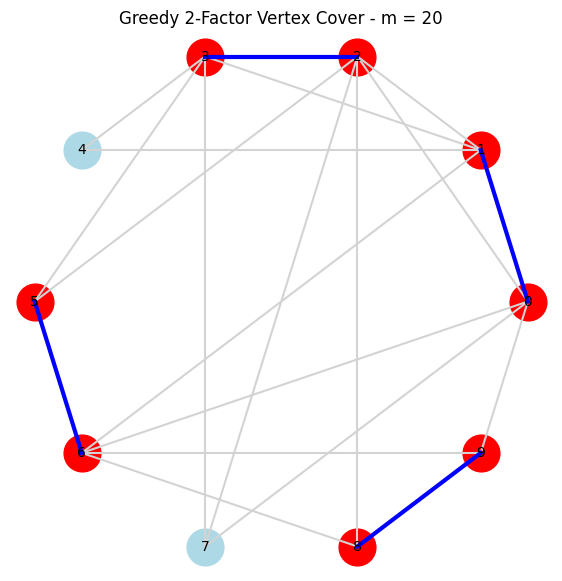

25        | 5               | 10                  | 6                 | 1.67            | 0.00001120               
Matching = [(3, 9), (0, 8), (5, 6), (2, 4), (1, 7)]
Vertex Cover = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)



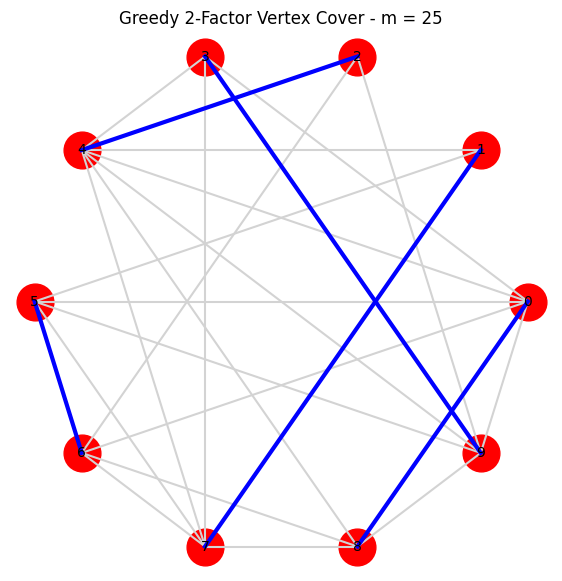

30        | 4               | 8                   | 7                 | 1.14            | 0.00001224               
Matching = [(2, 9), (1, 6), (0, 5), (3, 4)]
Vertex Cover = (0, 1, 2, 3, 4, 5, 6, 9)



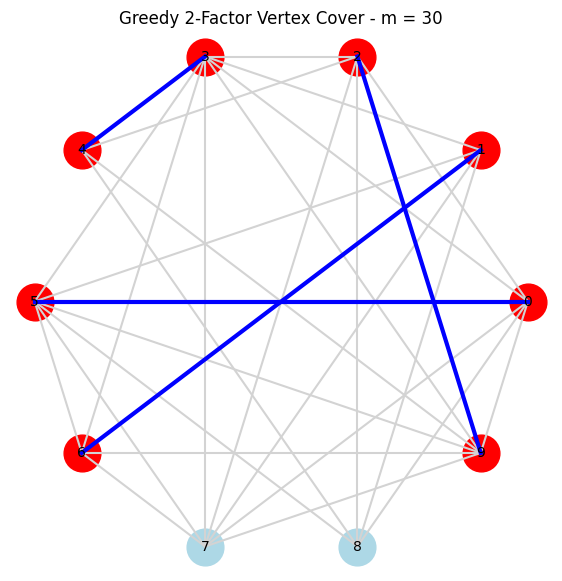

35        | 4               | 8                   | 7                 | 1.14            | 0.00001263               
Matching = [(3, 5), (6, 9), (1, 2), (0, 4)]
Vertex Cover = (0, 1, 2, 3, 4, 5, 6, 9)



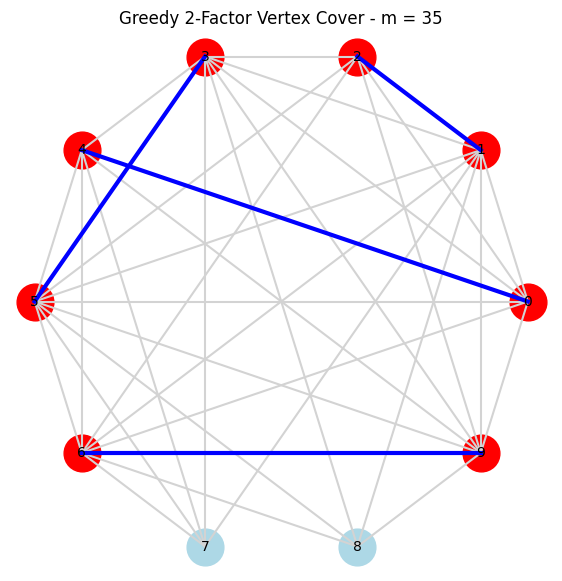

40        | 5               | 10                  | 8                 | 1.25            | 0.00001322               
Matching = [(0, 8), (7, 9), (2, 3), (1, 4), (5, 6)]
Vertex Cover = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)



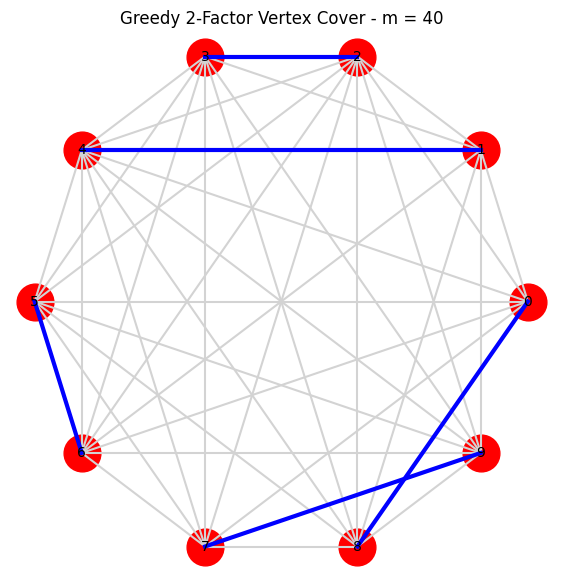

45        | 5               | 10                  | 9                 | 1.11            | 0.00001281               
Matching = [(5, 7), (0, 6), (4, 9), (1, 3), (2, 8)]
Vertex Cover = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)



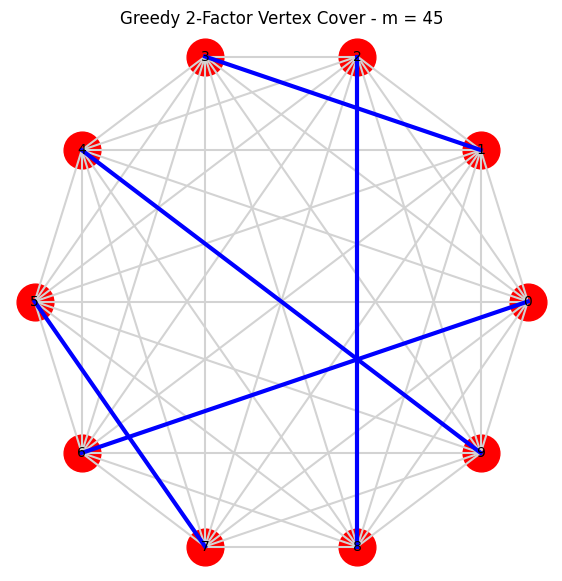

In [5]:
import json
import matplotlib.pyplot as plt
import math
import time
import itertools


def is_vertex_cover(edges, subset):
    for u, v in edges:
        if u not in subset and v not in subset:
            return False
    return True


def find_optimal_vertex_cover(n, edges):
    for k in range(n + 1):
        for subset in itertools.combinations(range(n), k):
            if is_vertex_cover(edges, subset):
                return k, subset


def greedy_matching(edges):
    matching = []
    matched_vertices = set()

    for u, v in edges:
        if u not in matched_vertices and v not in matched_vertices:
            matching.append((u, v))
            matched_vertices.add(u)
            matched_vertices.add(v)

    return matching


def greedy_2factor_vertex_cover(edges):
    matching = greedy_matching(edges)

    vertex_cover = set()

    for u, v in matching:
        vertex_cover.add(u)
        vertex_cover.add(v)

    return matching, tuple(sorted(vertex_cover))


with open("vertex_cover_datasets.json", "r") as file:
    datasets = json.load(file)


results = []

print(
    f"{'m(Edges)':<10}| "
    f"{'Matching Size':<16}| "
    f"{'Vertex Cover Size':<20}| "
    f"{'Optimal VC Size':<18}| "
    f"{'Approx. Factor':<16}| "
    f"{'Running Time (seconds)':<25}"
)

print("-" * 115)


for dataset in datasets:

    n = dataset["n"]
    m = dataset["m"]
    edges = [tuple(edge) for edge in dataset["edges"]]

    start_time = time.perf_counter()

    matching, vertex_cover = greedy_2factor_vertex_cover(edges)

    end_time = time.perf_counter()

    running_time = end_time - start_time

    optimal_size, optimal_cover = find_optimal_vertex_cover(n, edges)

    matching_size = len(matching)
    vertex_cover_size = len(vertex_cover)

    approximation_factor = vertex_cover_size / optimal_size

    print(
        f"{m:<10}| "
        f"{matching_size:<16}| "
        f"{vertex_cover_size:<20}| "
        f"{optimal_size:<18}| "
        f"{approximation_factor:<16.2f}| "
        f"{running_time:<25.8f}"
    )


    print("Matching =", matching)
    print("Vertex Cover =", vertex_cover)
    print()


    results.append({
        "n": n,
        "m": m,
        "matching": matching,
        "matching_size": matching_size,
        "vertex_cover": vertex_cover,
        "vertex_cover_size": vertex_cover_size,
        "optimal_vertex_cover_size": optimal_size,
        "approximation_factor": approximation_factor,
        "running_time": running_time
    })


    positions = {}

    for i in range(n):
        angle = 2 * math.pi * i / n
        x = 5 * math.cos(angle)
        y = 5 * math.sin(angle)
        positions[i] = (x, y)


    plt.figure(figsize=(7, 7))


    for u, v in edges:

        x1, y1 = positions[u]
        x2, y2 = positions[v]

        plt.plot(
            [x1, x2],
            [y1, y2],
            color="lightgray"
        )


    for u, v in matching:

        x1, y1 = positions[u]
        x2, y2 = positions[v]

        plt.plot(
            [x1, x2],
            [y1, y2],
            color="blue",
            linewidth=3
        )


    for vertex in range(n):

        x, y = positions[vertex]

        if vertex in vertex_cover:
            plt.scatter(
                x, y,
                s=700,
                color="red"
            )
        else:
            plt.scatter(
                x, y,
                s=700,
                color="lightblue"
            )

        plt.text(
            x,
            y,
            str(vertex),
            ha="center",
            va="center"
        )


    plt.title("Greedy 2-Factor Vertex Cover - m = " + str(m))
    plt.axis("off")
    plt.show()


with open("vertex_cover_p2_results.json", "w") as file:
    json.dump(results, file, indent=4)